# Extreme Criticality Evaluation: GNN+EBM Pipeline vs MILP

This notebook evaluates the pipeline on **extreme-criticality** scenarios designed to
almost certainly hit the MILP solver time limit (MaxTimeLimit).

**Targeted criticality drivers:**
- **PRIMARY**: B1 (zones), B3 (binaries), A5 (demand scale), A6 (peak/firm)
- **SECONDARY**: B8 (SOC tightness), B10 (network heterogeneity), A11 (trade reliance), A12 (inv congestion)

**Workflow:**
1. Install deps & mount Drive
2. Solve all 100 extreme scenarios with MILP (HiGHS, 1200s time limit)
3. Run the GNN+EBM pipeline on the same scenarios
4. Compare: solve time, cost gap, criticality decomposition

**Prerequisites:**
- Run `python -m scripts.generate_extreme_scenarios` locally first
- Upload `outputs/extreme_criticality_scenarios/` to Google Drive
- Models: `outputs/encoders/hierarchical_temporal_v3/best_encoder.pt`, `outputs/ebm_models/ebm_v3/ebm_v3_final.pt`

## 1. Install Dependencies

In [1]:
import subprocess, sys

print('Installing PyTorch 2.5.1 and PyTorch Geometric...')

subprocess.run([sys.executable, '-m', 'pip', 'uninstall', '-y',
    'torch', 'torchvision', 'torchaudio', 'torch-scatter', 'torch-sparse', 'torch-geometric'],
    capture_output=True)

!pip install -q torch==2.5.1+cu124 torchvision==0.20.1+cu124 torchaudio==2.5.1+cu124 --index-url https://download.pytorch.org/whl/cu124
!pip install -q torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-2.5.1+cu124.html
!pip install -q torch-geometric
!pip install -q numpy scipy tqdm pandas matplotlib seaborn scikit-learn pyomo highspy thrml

print('Dependencies installed')

Installing PyTorch 2.5.1 and PyTorch Geometric...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 908.2/908.2 MB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 93.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 87.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 73.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 63.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 84.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 11.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 37.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 19.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.8

## 2. Mount Drive & Setup Paths

In [1]:
import importlib, sys

modules_to_clear = [m for m in sys.modules if m.startswith('src.')]
for m in modules_to_clear:
    del sys.modules[m]
print(f'Cleared {len(modules_to_clear)} cached modules')

Cleared 0 cached modules


In [2]:
import os, sys, json, time, pickle
import numpy as np
import pandas as pd
import torch
from pathlib import Path
from typing import Dict, List, Optional, Tuple, Any
from tqdm.auto import tqdm
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

REPO_PATH = Path('/content/drive/MyDrive/benchmark')
sys.path.insert(0, str(REPO_PATH))
os.chdir(REPO_PATH)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Repo: {REPO_PATH}')
print(f'Device: {DEVICE}')
print(f'GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None"}')

Mounted at /content/drive
Repo: /content/drive/MyDrive/benchmark
Device: cuda
GPU: NVIDIA A100-SXM4-40GB


In [3]:
import shutil, glob

pycache_dirs = glob.glob(str(REPO_PATH / 'src/**/__pycache__'), recursive=True)
for d in pycache_dirs:
    shutil.rmtree(d)
print(f'Purged {len(pycache_dirs)} __pycache__ directories')

# Verify critical fixes
lp_src = (REPO_PATH / 'src/milp/lp_worker_two_stage.py').read_text(encoding='utf-8')
assert 'import_mode[t].fix(1.0)' not in lp_src, 'BUG: old import_mode fix still present!'
feas_src = (REPO_PATH / 'src/ebm/feasibility.py').read_text(encoding='utf-8')
assert 'ebm_therm = u_relax' in feas_src, 'BUG: decoder v5 EBM-guided fix missing!'
runner_src = (REPO_PATH / 'src/eval/pipeline_runner.py').read_text(encoding='utf-8')
assert "init_mode='bernoulli'" in runner_src, 'BUG: sampler init_mode fix missing!'
print('All fixes verified')

Purged 9 __pycache__ directories
All fixes verified


## 3. Configuration

In [4]:
EXTREME_DIR = REPO_PATH / 'outputs/extreme_criticality_scenarios'
REPORTS_DIR = EXTREME_DIR / 'reports'
OUTPUT_DIR  = REPO_PATH / 'outputs/pipeline_eval_extreme'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

sc_count = len(list(EXTREME_DIR.glob('scenario_*.json')))
rp_count = len(list(REPORTS_DIR.glob('scenario_*.json'))) if REPORTS_DIR.exists() else 0
print(f'Extreme scenarios: {sc_count}')
print(f'MILP reports:      {rp_count}')

# Load manifest
manifest_path = EXTREME_DIR / 'manifest.json'
if manifest_path.exists():
    with open(manifest_path) as f:
        manifest = json.load(f)
    stats = manifest['criticality_stats']
    print(f'\nCriticality: mean={stats["mean"]:.3f} [{stats["min"]:.3f}-{stats["max"]:.3f}]')
    print(f'P10={stats["p10"]:.3f}, P90={stats["p90"]:.3f}')

Extreme scenarios: 100
MILP reports:      100

Criticality: mean=0.541 [0.534-0.559]
P10=0.534, P90=0.549


## 4. Solve with MILP (HiGHS, 1200s time limit)

This step solves each scenario using the full MILP solver.
Already-solved scenarios are skipped automatically.

In [5]:
from src.milp.solve import solve_scenario
from src.milp.batch_runner import _serialize_report
import logging

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
TIME_LIMIT = 1200.0  # seconds

scenario_files = sorted(EXTREME_DIR.glob('scenario_*.json'))
print(f'Solving {len(scenario_files)} extreme scenarios (time limit={TIME_LIMIT}s)\n')

milp_results = []
for idx, sc_path in enumerate(tqdm(scenario_files, desc='MILP Solve'), 1):
    sc_id = sc_path.stem
    report_path = REPORTS_DIR / f'{sc_id}.json'

    if report_path.exists():
        milp_results.append({'scenario_id': sc_id, 'status': 'skipped'})
        continue

    try:
        report = solve_scenario(
            sc_path,
            solver_name='highs',
            tee=False,
            capture_detail=True,
            time_limit_seconds=TIME_LIMIT,
        )
        serialized = _serialize_report(report)
        with open(report_path, 'w', encoding='utf-8') as f:
            json.dump(serialized, f, indent=2)

        obj = report['mip'].objective
        status = report['mip'].termination_condition.name
        solve_time = report['mip'].solve_seconds
        tqdm.write(f'  {sc_id}: obj={obj:,.0f} status={status} time={solve_time:.1f}s')
        milp_results.append({'scenario_id': sc_id, 'status': 'ok',
                             'objective': obj, 'solve_time': solve_time,
                             'termination': status})
    except Exception as e:
        tqdm.write(f'  {sc_id}: FAILED - {e}')
        milp_results.append({'scenario_id': sc_id, 'status': 'failed', 'error': str(e)})

ok_count = sum(1 for r in milp_results if r['status'] in ('ok', 'skipped'))
fail_count = sum(1 for r in milp_results if r['status'] == 'failed')
print(f'\nDone: {ok_count} success, {fail_count} failed')

# Check termination distribution
from collections import Counter
terms = []
for rp in REPORTS_DIR.glob('scenario_*.json'):
    with open(rp) as f:
        d = json.load(f)
    terms.append(d.get('mip', {}).get('termination_condition', 'unknown'))
print(f'Termination distribution: {dict(Counter(terms))}')

Solving 100 extreme scenarios (time limit=1200.0s)



MILP Solve:   0%|          | 0/100 [00:00<?, ?it/s]


Done: 100 success, 0 failed
Termination distribution: {'unknown': 100}


## 5. Run Pipeline on Extreme Scenarios

In [6]:
from src.eval.pipeline_runner import PipelineConfig, PipelineRunner

config = PipelineConfig(
    repo_path=str(REPO_PATH),
    encoder_path='outputs/encoders/hierarchical_temporal_v3/best_encoder.pt',
    ebm_path='outputs/ebm_models/ebm_v3/ebm_v3_final.pt',
    node_feature_dim=14,
    hidden_dim=128,
    num_spatial_layers=2,
    num_temporal_layers=4,
    num_heads=8,
    dropout=0.1,
    embed_dim=128,
    n_features=7,
    n_timesteps=24,
    langevin_steps=100,
    step_size=0.05,
    noise_scale=0.5,
    init_temp=1.0,
    final_temp=0.1,
    n_samples=5,
    solver_name='appsi_highs',
    device=DEVICE,
    seed=42,
)

torch.manual_seed(config.seed)
np.random.seed(config.seed)

runner = PipelineRunner(config)
runner.load_models()

Loading HTE encoder...
  Encoder loaded: 3,185,664 params
Loading EBM v3...
  EBM loaded: 553,729 params
  Sampler ready (infer mode)


In [7]:
import shutil

graphs_dir = OUTPUT_DIR / 'graphs'
if graphs_dir.exists():
    shutil.rmtree(graphs_dir)
    print('Cleared stale graph cache')

results = runner.evaluate_family(
    scenarios_dir=EXTREME_DIR,
    reports_dir=REPORTS_DIR,
    graphs_dir=graphs_dir,
    family_name='extreme',
)

runner.save_results(results, OUTPUT_DIR / 'pipeline_eval_extreme.pkl')
print(f'\nTotal: {len(results)} scenarios evaluated')


Evaluating 100 scenarios from extreme


Pipeline [extreme]:   0%|          | 0/100 [00:00<?, ?it/s]

Saved 100 results to /content/drive/MyDrive/benchmark/outputs/pipeline_eval_extreme/pipeline_eval_extreme.pkl

Total: 100 scenarios evaluated


## 6. Build Comparison DataFrame

In [8]:
from src.eval.metrics import (
    compute_eval_metrics, format_metrics_table,
)
from dataclasses import asdict

results_path = OUTPUT_DIR / 'pipeline_eval_extreme.pkl'
if results_path.exists():
    pipeline_results = PipelineRunner.load_results(results_path)
else:
    pipeline_results = [asdict(r) for r in results]

milp_reports_dirs = {'extreme': REPORTS_DIR}
eval_output = compute_eval_metrics(pipeline_results, milp_reports_dirs)
df = eval_output['dataframe']

print(f'DataFrame: {df.shape}')
print(f'Success rate: {df["success"].mean()*100:.1f}%')
print(f'Termination distribution:')
print(df['milp_termination'].value_counts().to_string())
df.head(10)

DataFrame: (100, 26)
Success rate: 100.0%
Termination distribution:
milp_termination
maxTimeLimit    100


,scenario_id,family,pipeline_objective,pipeline_solve_time,pipeline_status,pipeline_stage,pipeline_slack,pipeline_n_flips,n_zones,n_timesteps,...,time_ebm_sampling,time_decoder,time_lp_solve,milp_objective,milp_solve_time,milp_status,milp_termination,speedup,cost_gap_pct,cost_gap_abs
0,scenario_00001,extreme,1.910624e+06,361.427858,optimal,repair_20,0.0,1,221,24,...,1.979000,8.153730,349.916626,-3.788281e+07,1211.109440,aborted,maxTimeLimit,3.350902,105.043510,3.979344e+07
1,scenario_00002,extreme,5.061406e+07,282.403525,optimal,repair_20,0.0,1,240,24,...,1.956410,8.771497,270.996763,4.545931e+06,1210.829128,aborted,maxTimeLimit,4.287585,1013.392675,4.606813e+07
2,scenario_00003,extreme,4.293376e+07,244.500280,optimal,repair_20,0.0,1,203,24,...,1.822021,7.273257,234.826376,1.394126e+07,1208.721564,aborted,maxTimeLimit,4.943641,207.961936,2.899251e+07
3,scenario_00004,extreme,6.544178e+06,319.383252,optimal,repair_20,0.0,1,216,24,...,1.851408,8.073942,308.852404,-3.684121e+07,1208.911177,aborted,maxTimeLimit,3.785143,117.763202,4.338538e+07
4,scenario_00005,extreme,5.421224e+07,343.323450,optimal,repair_20,0.0,0,260,24,...,1.941585,9.484808,331.166487,3.577945e+06,1210.332494,aborted,maxTimeLimit,3.525342,1415.178221,5.063430e+07
5,scenario_00006,extreme,3.013505e+07,209.872644,optimal,repair_20,0.0,0,252,24,...,1.955112,9.253875,197.956048,-1.286152e+07,1209.992468,aborted,maxTimeLimit,5.765365,334.303971,4.299656e+07
6,scenario_00007,extreme,-5.090663e+06,249.767261,optimal,hard_fix,0.0,0,211,24,...,1.824376,7.696914,239.656076,-5.744355e+07,1207.961959,aborted,maxTimeLimit,4.836350,91.137972,5.235289e+07
7,scenario_00008,extreme,6.949223e+07,162.789445,optimal,hard_fix,0.0,0,229,24,...,1.924913,8.199189,152.031902,2.939624e+07,1208.448846,aborted,maxTimeLimit,7.423386,136.398361,4.009599e+07
8,scenario_00009,extreme,4.675784e+07,223.531823,optimal,repair_20,0.0,1,214,24,...,1.844996,7.790145,213.292804,1.689468e+07,1208.088392,aborted,maxTimeLimit,5.404548,176.760759,2.986316e+07
9,scenario_00010,extreme,4.743926e+07,174.861464,optimal,hard_fix,0.0,0,215,24,...,1.850795,7.857278,164.539142,1.733504e+07,1208.906633,aborted,maxTimeLimit,6.913511,173.661070,3.010422e+07


## 7. P90-P99 Metrics

In [9]:
print(format_metrics_table(eval_output['global'], 'Extreme Criticality (all scenarios)'))

# Split by MILP termination
df_tl = df[df['milp_termination'] == 'maxTimeLimit']
df_opt = df[df['milp_termination'] == 'optimal']
print(f'MaxTimeLimit: {len(df_tl)} scenarios')
print(f'Optimal:      {len(df_opt)} scenarios')
print(f'MaxTimeLimit rate: {len(df_tl)/max(len(df),1)*100:.0f}%')


  Extreme Criticality (all scenarios) Evaluation Metrics

  cost_gap_pct:
    Mean: 519.63 (std: 2035.12)
    Median: 119.63
    [P10, P90]: [58.42, 602.21]
    [P95, P99]: [1420.36, 6885.96]

  speedup:
    Mean: 5.82 (std: 1.66)
    Median: 5.41
    [P10, P90]: [3.86, 8.19]
    [P95, P99]: [8.47, 9.33]

  pipeline_time_s:
    Mean: 224.87 (std: 65.42)
    Median: 223.38
    [P10, P90]: [147.69, 313.15]
    [P95, P99]: [343.37, 438.75]

  slack_mwh:
    Mean: 0.01 (std: 0.09)
    Median: 0.00
    [P10, P90]: [0.00, 0.00]
    [P95, P99]: [0.00, 0.01]

  Stage Distribution:
    hard_fix: 48.0%
    repair_20: 46.0%
    full_soft: 6.0%
MaxTimeLimit: 100 scenarios
Optimal:      0 scenarios
MaxTimeLimit rate: 100%


## 8. Solve Time & Cost Gap Analysis

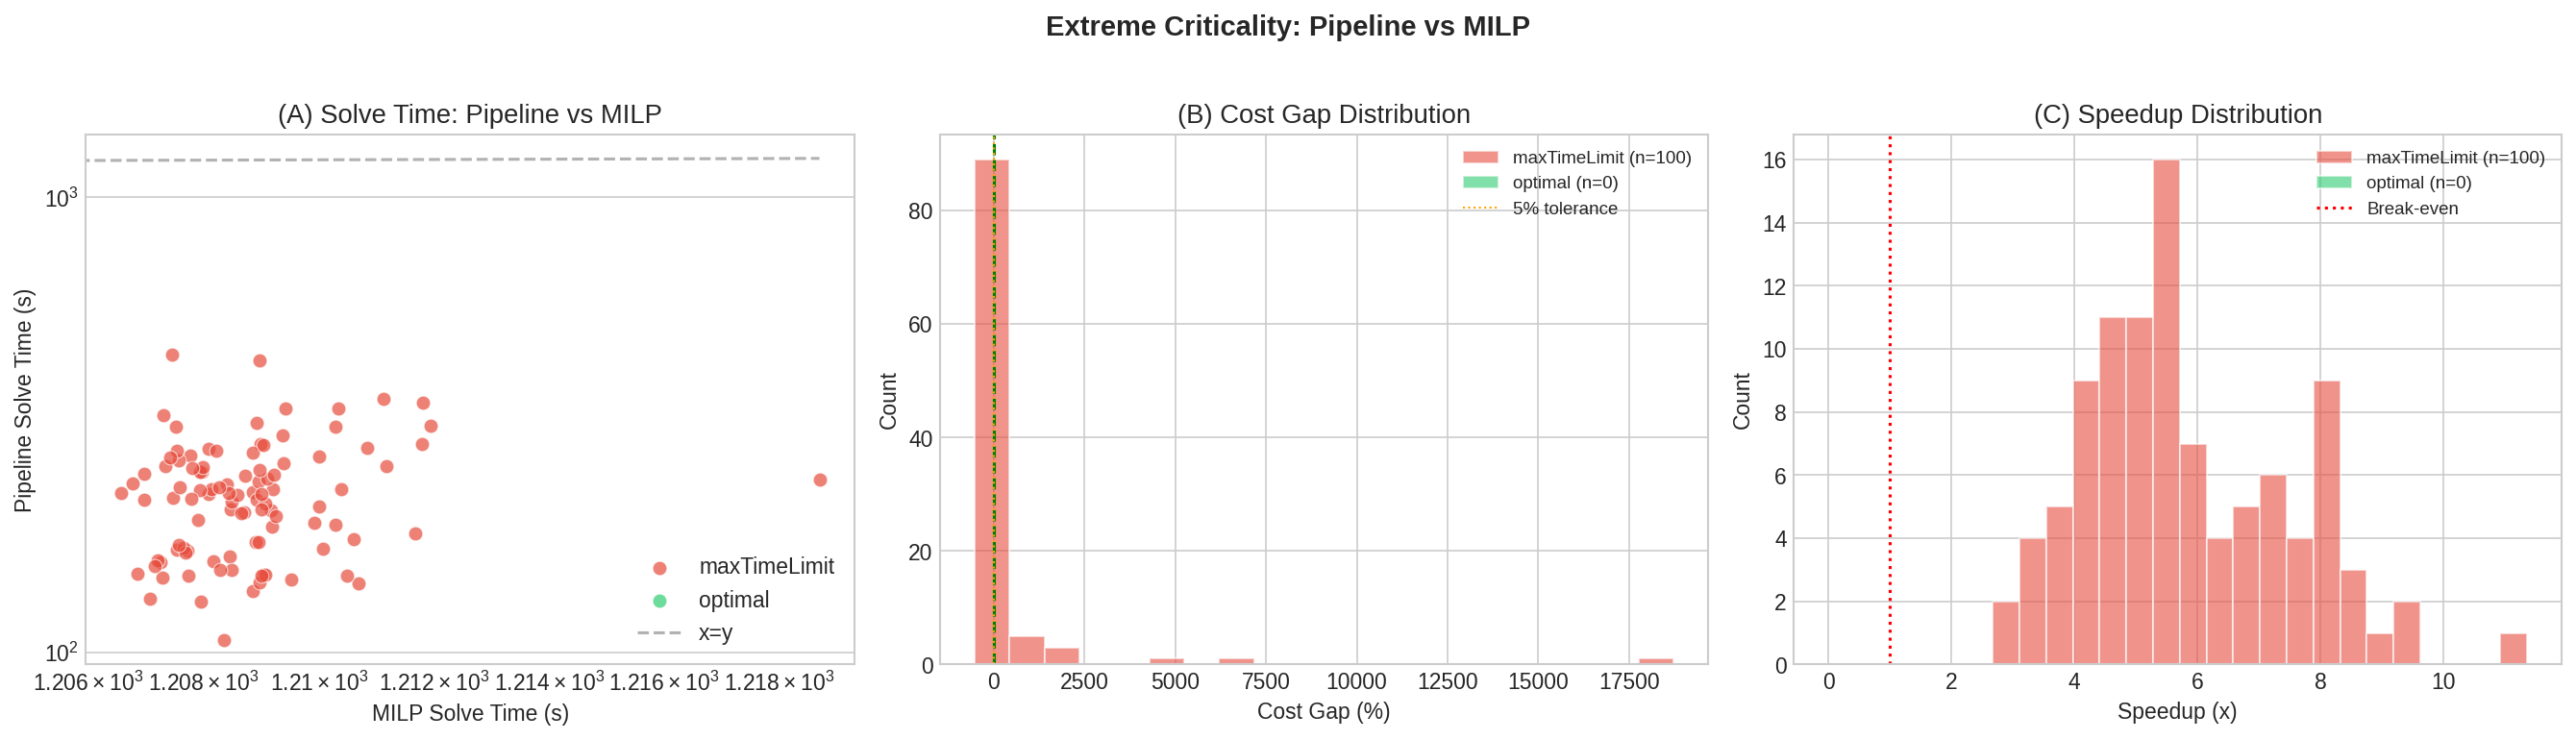


MaxTimeLimit subset (n=100):
  Pipeline time: mean=224.9s, median=223.4s
  MILP time:     mean=1208.8s
  Speedup:       mean=5.8x, median=5.4x
  Cost gap:      P50=119.6%, P90=602.2%
  Pipeline better: 6/100 (6%)


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 11

TERM_COLORS = {'maxTimeLimit': '#e74c3c', 'optimal': '#2ecc71'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel A: Solve time comparison
ax = axes[0]
for term, color in TERM_COLORS.items():
    mask = df['milp_termination'] == term
    ax.scatter(df.loc[mask, 'milp_solve_time'], df.loc[mask, 'pipeline_solve_time'],
              c=color, label=term, s=50, alpha=0.7, edgecolors='white', linewidth=0.5)
ax.plot([0, df['milp_solve_time'].max()], [0, df['milp_solve_time'].max()],
        'k--', alpha=0.3, label='x=y')
ax.set_xlabel('MILP Solve Time (s)')
ax.set_ylabel('Pipeline Solve Time (s)')
ax.set_title('(A) Solve Time: Pipeline vs MILP')
ax.legend()
ax.set_xscale('log'); ax.set_yscale('log')

# Panel B: Cost gap distribution
ax = axes[1]
for term, color in TERM_COLORS.items():
    mask = df['milp_termination'] == term
    sub = df.loc[mask, 'cost_gap_pct'].dropna()
    ax.hist(sub, bins=20, alpha=0.6, color=color, label=f'{term} (n={len(sub)})',
            edgecolor='white')
ax.axvline(x=0, color='green', linestyle='--', lw=1.5)
ax.axvline(x=5, color='orange', linestyle=':', lw=1, label='5% tolerance')
ax.set_xlabel('Cost Gap (%)')
ax.set_ylabel('Count')
ax.set_title('(B) Cost Gap Distribution')
ax.legend(fontsize=9)

# Panel C: Speedup distribution
ax = axes[2]
for term, color in TERM_COLORS.items():
    mask = df['milp_termination'] == term
    sub = df.loc[mask, 'speedup'].dropna()
    ax.hist(sub, bins=20, alpha=0.6, color=color, label=f'{term} (n={len(sub)})',
            edgecolor='white')
ax.axvline(x=1, color='red', linestyle=':', lw=1.5, label='Break-even')
ax.set_xlabel('Speedup (x)')
ax.set_ylabel('Count')
ax.set_title('(C) Speedup Distribution')
ax.legend(fontsize=9)

fig.suptitle('Extreme Criticality: Pipeline vs MILP', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig1_extreme_solve_time_cost_gap.png', dpi=300, bbox_inches='tight')
plt.show()

# Summary stats
print(f'\nMaxTimeLimit subset (n={len(df_tl)}):')
print(f'  Pipeline time: mean={df_tl["pipeline_solve_time"].mean():.1f}s, median={df_tl["pipeline_solve_time"].median():.1f}s')
print(f'  MILP time:     mean={df_tl["milp_solve_time"].mean():.1f}s')
print(f'  Speedup:       mean={df_tl["speedup"].mean():.1f}x, median={df_tl["speedup"].median():.1f}x')
print(f'  Cost gap:      P50={df_tl["cost_gap_pct"].median():.1f}%, P90={np.percentile(df_tl["cost_gap_pct"].dropna(), 90):.1f}%')
n_better = (df_tl['cost_gap_pct'] < 0).sum()
print(f'  Pipeline better: {n_better}/{len(df_tl)} ({n_better/max(len(df_tl),1)*100:.0f}%)')

## 9. Stage Distribution & Timing Breakdown

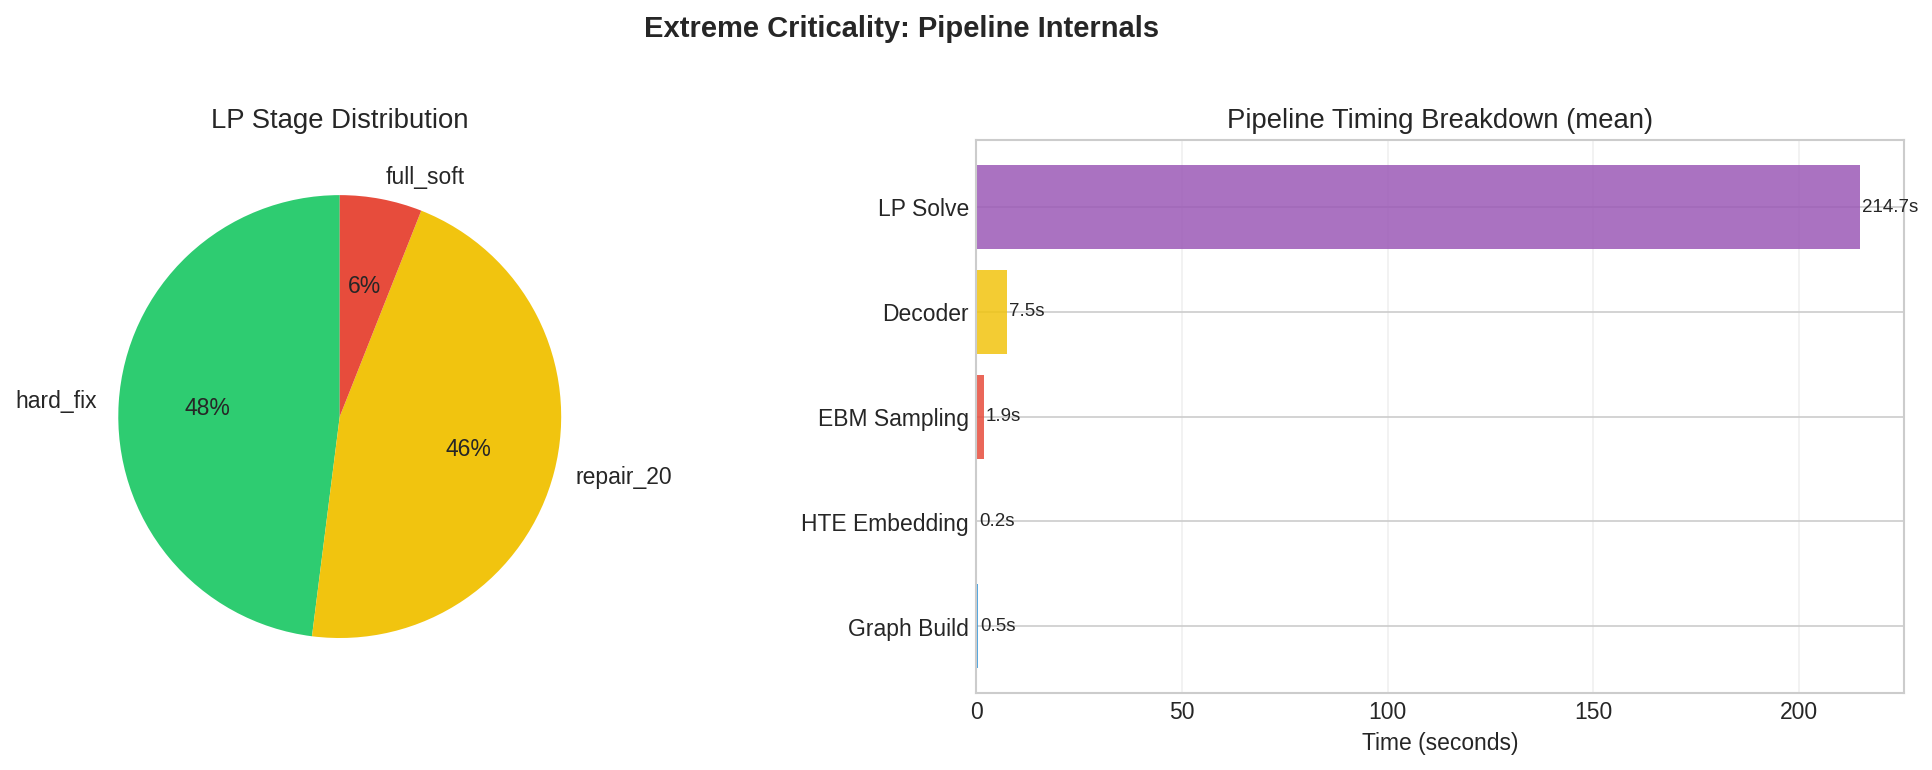

In [11]:
STAGE_COLORS = {'hard_fix': '#2ecc71', 'repair_20': '#f1c40f', 'repair_100': '#e67e22', 'full_soft': '#e74c3c'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: Stage distribution pie
ax = axes[0]
stage_counts = df['pipeline_stage'].value_counts()
colors = [STAGE_COLORS.get(s, 'gray') for s in stage_counts.index]
ax.pie(stage_counts.values, labels=stage_counts.index, colors=colors,
       autopct='%1.0f%%', startangle=90)
ax.set_title('LP Stage Distribution')

# Panel B: Timing breakdown
ax = axes[1]
timing_cols = ['time_graph_build', 'time_embedding', 'time_ebm_sampling', 'time_decoder', 'time_lp_solve']
timing_labels = ['Graph Build', 'HTE Embedding', 'EBM Sampling', 'Decoder', 'LP Solve']
timing_colors = ['#3498db', '#2ecc71', '#e74c3c', '#f1c40f', '#9b59b6']
means = [df[col].mean() for col in timing_cols]
ax.barh(timing_labels, means, color=timing_colors, alpha=0.85)
for i, v in enumerate(means):
    ax.text(v + 0.5, i, f'{v:.1f}s', va='center', fontsize=9)
ax.set_xlabel('Time (seconds)')
ax.set_title('Pipeline Timing Breakdown (mean)')
ax.grid(True, alpha=0.3, axis='x')

fig.suptitle('Extreme Criticality: Pipeline Internals', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig2_extreme_stage_timing.png', dpi=300, bbox_inches='tight')
plt.show()

## 10. Criticality Index Decomposition

In [12]:
from src.analysis.criticality_index import (
    compute_criticality, NORM_BOUNDS,
)
from dataclasses import asdict as dc_asdict

# Compute full criticality decomposition for every extreme scenario
crit_records = []
for sc_path in sorted(EXTREME_DIR.glob('scenario_*.json')):
    with open(sc_path, 'r', encoding='utf-8') as f:
        scenario = json.load(f)
    result = compute_criticality(scenario, alpha=0.5)
    rec = {
        'scenario_id': sc_path.stem,
        'criticality_index': result.criticality_index,
        'stress_index': result.stress_index,
        'hardness_index': result.hardness_index,
        **{f'{k}_norm': v for k, v in result.stress_normalized.items()},
        **{f'{k}_norm': v for k, v in result.hardness_normalized.items()},
    }
    crit_records.append(rec)

df_crit = pd.DataFrame(crit_records)
print(f'Criticality decomposition: {len(df_crit)} scenarios')
print(f'  Criticality: mean={df_crit["criticality_index"].mean():.4f} '
      f'[{df_crit["criticality_index"].min():.4f}, {df_crit["criticality_index"].max():.4f}]')
print(f'  Stress:      mean={df_crit["stress_index"].mean():.4f}')
print(f'  Hardness:    mean={df_crit["hardness_index"].mean():.4f}')

Criticality decomposition: 100 scenarios
  Criticality: mean=0.5413 [0.5336, 0.5588]
  Stress:      mean=0.6531
  Hardness:    mean=0.4296


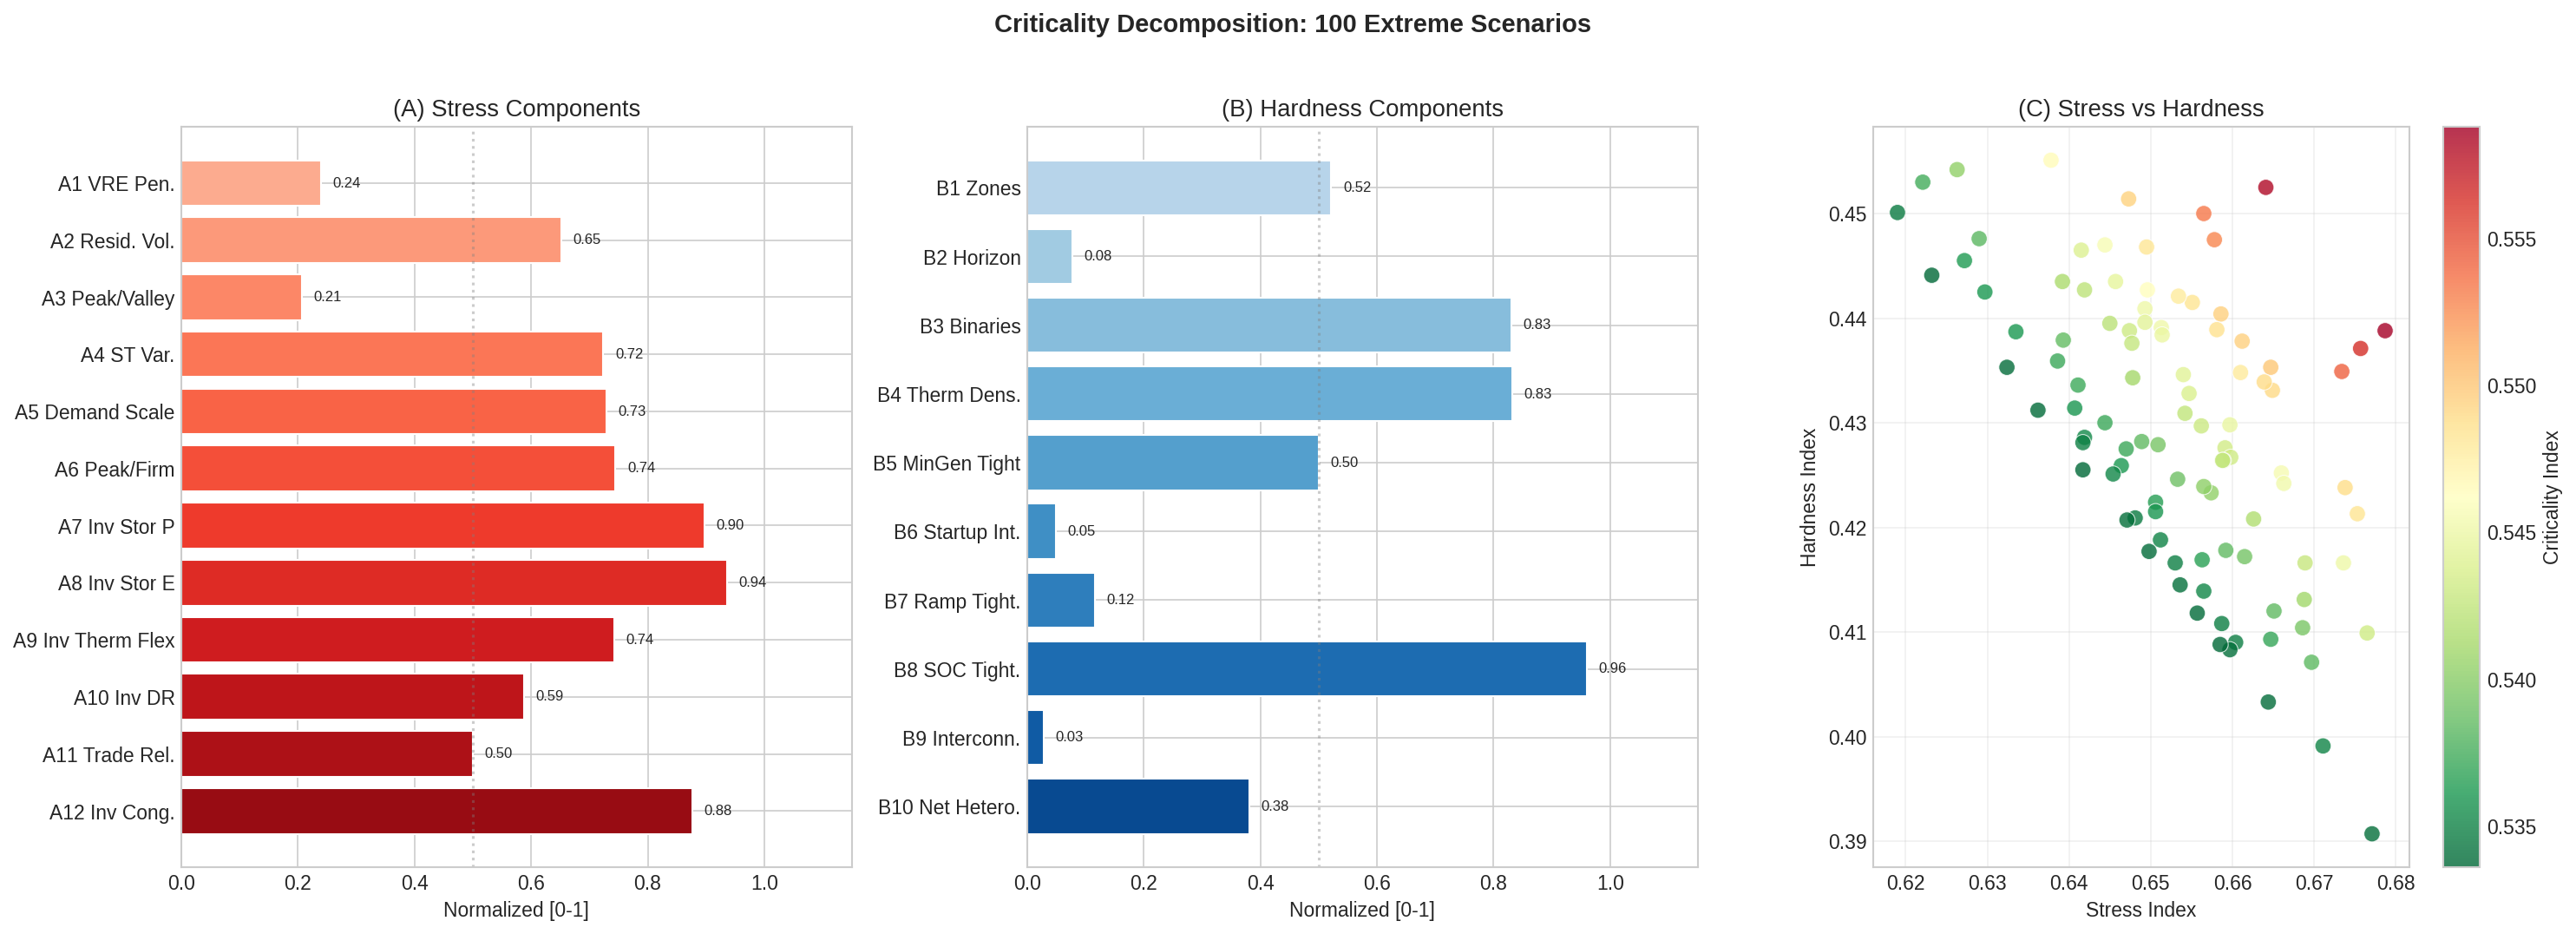


Top-5 criticality drivers:
  1. B8 SOC Tight.: 0.960
  2. A8 Inv Stor E: 0.935
  3. A7 Inv Stor P: 0.897
  4. A12 Inv Cong.: 0.877
  5. B4 Therm Dens.: 0.832


In [13]:
# Component bar charts
stress_labels = [
    'A1 VRE Pen.', 'A2 Resid. Vol.', 'A3 Peak/Valley', 'A4 ST Var.',
    'A5 Demand Scale', 'A6 Peak/Firm', 'A7 Inv Stor P', 'A8 Inv Stor E',
    'A9 Inv Therm Flex', 'A10 Inv DR', 'A11 Trade Rel.', 'A12 Inv Cong.',
]
hardness_labels = [
    'B1 Zones', 'B2 Horizon', 'B3 Binaries', 'B4 Therm Dens.',
    'B5 MinGen Tight', 'B6 Startup Int.', 'B7 Ramp Tight.',
    'B8 SOC Tight.', 'B9 Interconn.', 'B10 Net Hetero.',
]
stress_norm_cols = sorted([c for c in df_crit.columns if c.startswith('A') and c.endswith('_norm')],
                          key=lambda c: int(c.split('_')[0][1:]))
hardness_norm_cols = sorted([c for c in df_crit.columns if c.startswith('B') and c.endswith('_norm')],
                            key=lambda c: int(c.split('_')[0][1:]))
all_norm_cols = stress_norm_cols + hardness_norm_cols
all_labels = stress_labels + hardness_labels

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# Panel A: Stress components
ax = axes[0]
s_means = [df_crit[c].mean() for c in stress_norm_cols]
colors_s = plt.cm.Reds(np.linspace(0.3, 0.9, len(s_means)))
bars = ax.barh(stress_labels, s_means, color=colors_s, edgecolor='white')
for bar, val in zip(bars, s_means):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', fontsize=8)
ax.set_xlim(0, 1.15); ax.set_xlabel('Normalized [0-1]')
ax.set_title('(A) Stress Components')
ax.invert_yaxis(); ax.axvline(x=0.5, color='gray', linestyle=':', alpha=0.4)

# Panel B: Hardness components
ax = axes[1]
h_means = [df_crit[c].mean() for c in hardness_norm_cols]
colors_h = plt.cm.Blues(np.linspace(0.3, 0.9, len(h_means)))
bars = ax.barh(hardness_labels, h_means, color=colors_h, edgecolor='white')
for bar, val in zip(bars, h_means):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', fontsize=8)
ax.set_xlim(0, 1.15); ax.set_xlabel('Normalized [0-1]')
ax.set_title('(B) Hardness Components')
ax.invert_yaxis(); ax.axvline(x=0.5, color='gray', linestyle=':', alpha=0.4)

# Panel C: Stress vs Hardness scatter
ax = axes[2]
sc = ax.scatter(df_crit['stress_index'], df_crit['hardness_index'],
                c=df_crit['criticality_index'], cmap='RdYlGn_r',
                s=80, alpha=0.8, edgecolors='white', linewidth=0.5)
plt.colorbar(sc, ax=ax, label='Criticality Index')
ax.set_xlabel('Stress Index'); ax.set_ylabel('Hardness Index')
ax.set_title('(C) Stress vs Hardness'); ax.grid(True, alpha=0.3)

fig.suptitle(f'Criticality Decomposition: {len(df_crit)} Extreme Scenarios',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig3_extreme_criticality_decomposition.png', dpi=300, bbox_inches='tight')
plt.show()

# Top-5 drivers
driver_means = sorted(zip(all_labels, [df_crit[c].mean() for c in all_norm_cols]),
                      key=lambda x: x[1], reverse=True)
print('\nTop-5 criticality drivers:')
for rank, (lbl, val) in enumerate(driver_means[:5], 1):
    print(f'  {rank}. {lbl}: {val:.3f}')

## 11. Comparison: Extreme vs High-Crit Family

Load the high-criticality family results (from `evaluation_pipeline_fine_tuned.ipynb`) for comparison.

In [14]:
# Try to load the high-crit results from the main evaluation
high_results_path = REPO_PATH / 'outputs/pipeline_eval_criticality/pipeline_eval_all_families.pkl'
HIGH_DIR = REPO_PATH / 'outputs/high_criticality_scenarios'
HIGH_REPORTS = HIGH_DIR / 'reports'

if high_results_path.exists() and HIGH_REPORTS.exists():
    high_pipeline = PipelineRunner.load_results(high_results_path)
    high_pipeline = [r for r in high_pipeline if r.get('family') == 'high']
    high_eval = compute_eval_metrics(high_pipeline, {'high': HIGH_REPORTS})
    df_high = high_eval['dataframe']
    print(f'Loaded high-crit family: {len(df_high)} scenarios')
    HAS_HIGH = True
else:
    print('High-crit family results not found - skipping comparison')
    HAS_HIGH = False

Loaded high-crit family: 100 scenarios


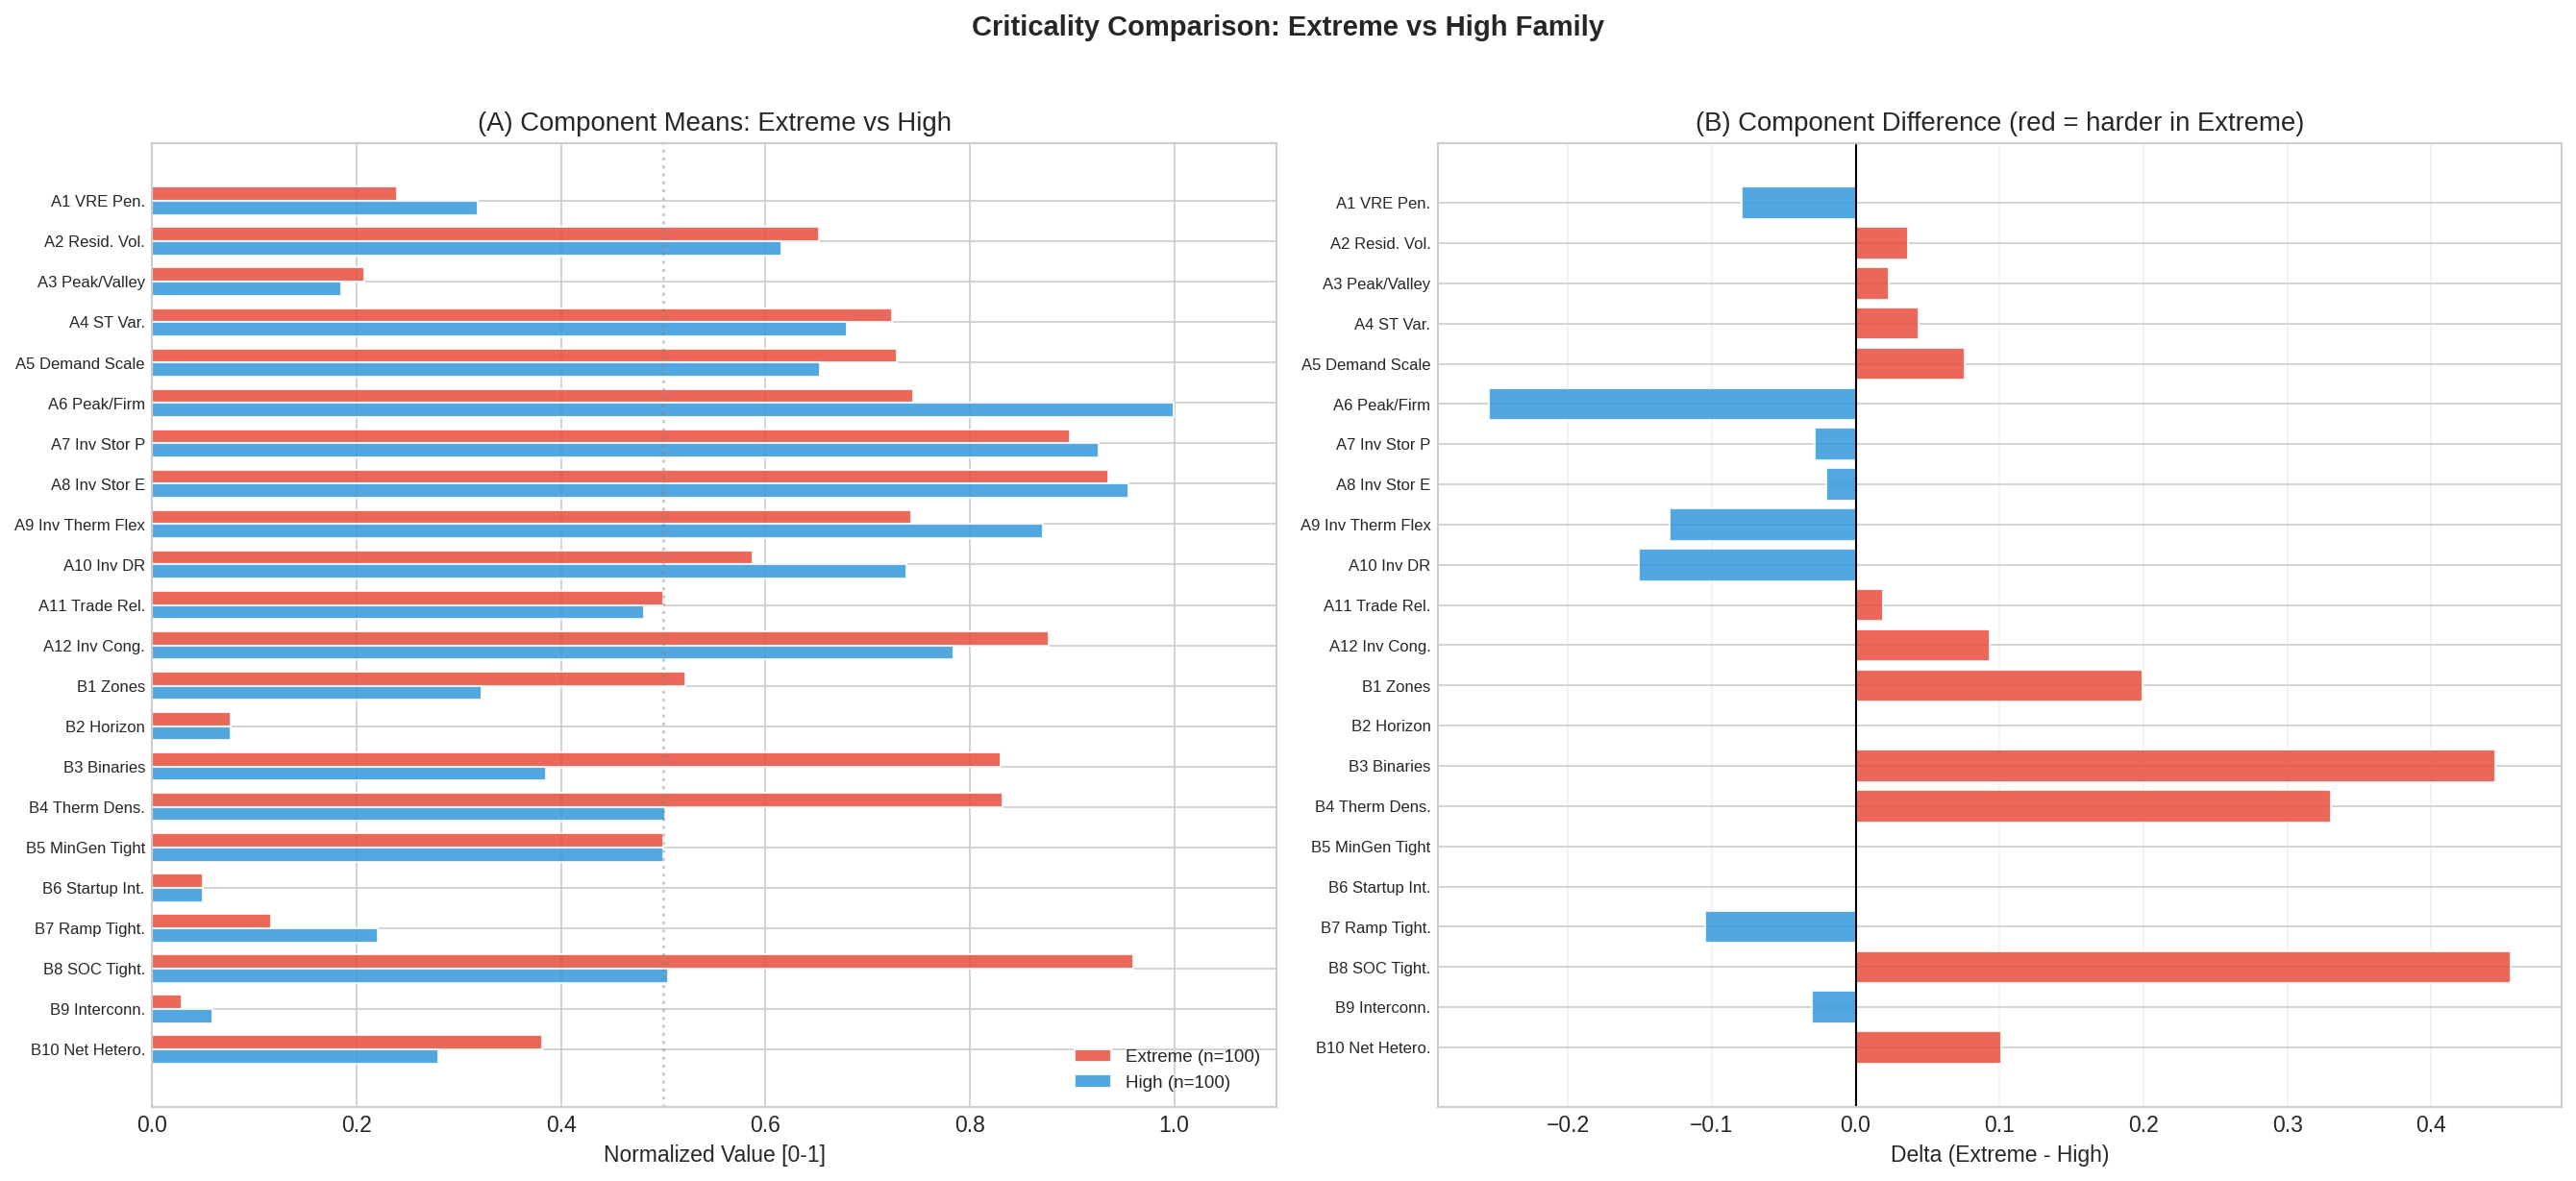

COMPARISON: Extreme vs High-Criticality Family
  Criticality :  EXT=0.5413+/-0.0062  HIGH=0.4870+/-0.0081  Delta=+0.0543
  Stress      :  EXT=0.6531+/-0.0129  HIGH=0.6840+/-0.0189  Delta=-0.0310
  Hardness    :  EXT=0.4296+/-0.0135  HIGH=0.2900+/-0.0218  Delta=+0.1396

  Top-5 components with biggest increase (Extreme > High):
    1. B8 SOC Tight.: Delta=+0.455
    2. B3 Binaries: Delta=+0.445
    3. B4 Therm Dens.: Delta=+0.330
    4. B1 Zones: Delta=+0.200
    5. B10 Net Hetero.: Delta=+0.101


In [15]:
if HAS_HIGH:
    # Compute criticality decomposition for high family
    crit_high = []
    for sc_path in sorted(HIGH_DIR.glob('scenario_*.json')):
        with open(sc_path, 'r', encoding='utf-8') as f:
            scenario = json.load(f)
        result = compute_criticality(scenario, alpha=0.5)
        rec = {
            'scenario_id': sc_path.stem,
            'criticality_index': result.criticality_index,
            'stress_index': result.stress_index,
            'hardness_index': result.hardness_index,
            **{f'{k}_norm': v for k, v in result.stress_normalized.items()},
            **{f'{k}_norm': v for k, v in result.hardness_normalized.items()},
        }
        crit_high.append(rec)
    df_crit_high = pd.DataFrame(crit_high)

    # Side-by-side comparison
    ext_means = [df_crit[c].mean() for c in all_norm_cols]
    high_means = [df_crit_high[c].mean() for c in all_norm_cols]

    fig, axes = plt.subplots(1, 2, figsize=(18, 8))

    # Panel A: Side-by-side bars
    ax = axes[0]
    y_pos = np.arange(len(all_labels))
    bar_h = 0.35
    ax.barh(y_pos - bar_h/2, ext_means, bar_h, label=f'Extreme (n={len(df_crit)})',
            color='#e74c3c', alpha=0.85, edgecolor='white')
    ax.barh(y_pos + bar_h/2, high_means, bar_h, label=f'High (n={len(df_crit_high)})',
            color='#3498db', alpha=0.85, edgecolor='white')
    ax.set_yticks(y_pos); ax.set_yticklabels(all_labels, fontsize=8)
    ax.set_xlabel('Normalized Value [0-1]')
    ax.set_title('(A) Component Means: Extreme vs High')
    ax.legend(loc='lower right', fontsize=9)
    ax.invert_yaxis(); ax.axvline(x=0.5, color='gray', linestyle=':', alpha=0.4)
    ax.set_xlim(0, 1.1)

    # Panel B: Delta
    ax = axes[1]
    deltas = [e - h for e, h in zip(ext_means, high_means)]
    colors_d = ['#e74c3c' if d > 0 else '#3498db' for d in deltas]
    ax.barh(y_pos, deltas, color=colors_d, alpha=0.85, edgecolor='white')
    ax.set_yticks(y_pos); ax.set_yticklabels(all_labels, fontsize=8)
    ax.set_xlabel('Delta (Extreme - High)')
    ax.set_title('(B) Component Difference (red = harder in Extreme)')
    ax.invert_yaxis(); ax.axvline(x=0, color='black', linewidth=1)
    ax.grid(True, alpha=0.3, axis='x')

    fig.suptitle('Criticality Comparison: Extreme vs High Family',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'fig4_extreme_vs_high_components.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Summary table
    print('=' * 90)
    print('COMPARISON: Extreme vs High-Criticality Family')
    print('=' * 90)
    for label, idx_col in [('Criticality', 'criticality_index'),
                            ('Stress', 'stress_index'),
                            ('Hardness', 'hardness_index')]:
        e_m, e_s = df_crit[idx_col].mean(), df_crit[idx_col].std()
        h_m, h_s = df_crit_high[idx_col].mean(), df_crit_high[idx_col].std()
        print(f'  {label:12s}:  EXT={e_m:.4f}+/-{e_s:.4f}  HIGH={h_m:.4f}+/-{h_s:.4f}  Delta={e_m-h_m:+.4f}')

    # Top-5 components with biggest increase
    sorted_d = sorted(zip(all_labels, deltas), key=lambda x: x[1], reverse=True)
    print('\n  Top-5 components with biggest increase (Extreme > High):')
    for rank, (lbl, d) in enumerate(sorted_d[:5], 1):
        print(f'    {rank}. {lbl}: Delta={d:+.3f}')
else:
    print('Skipping comparison (high-crit results not available)')

## 12. Economic Advantage (Extreme Family)

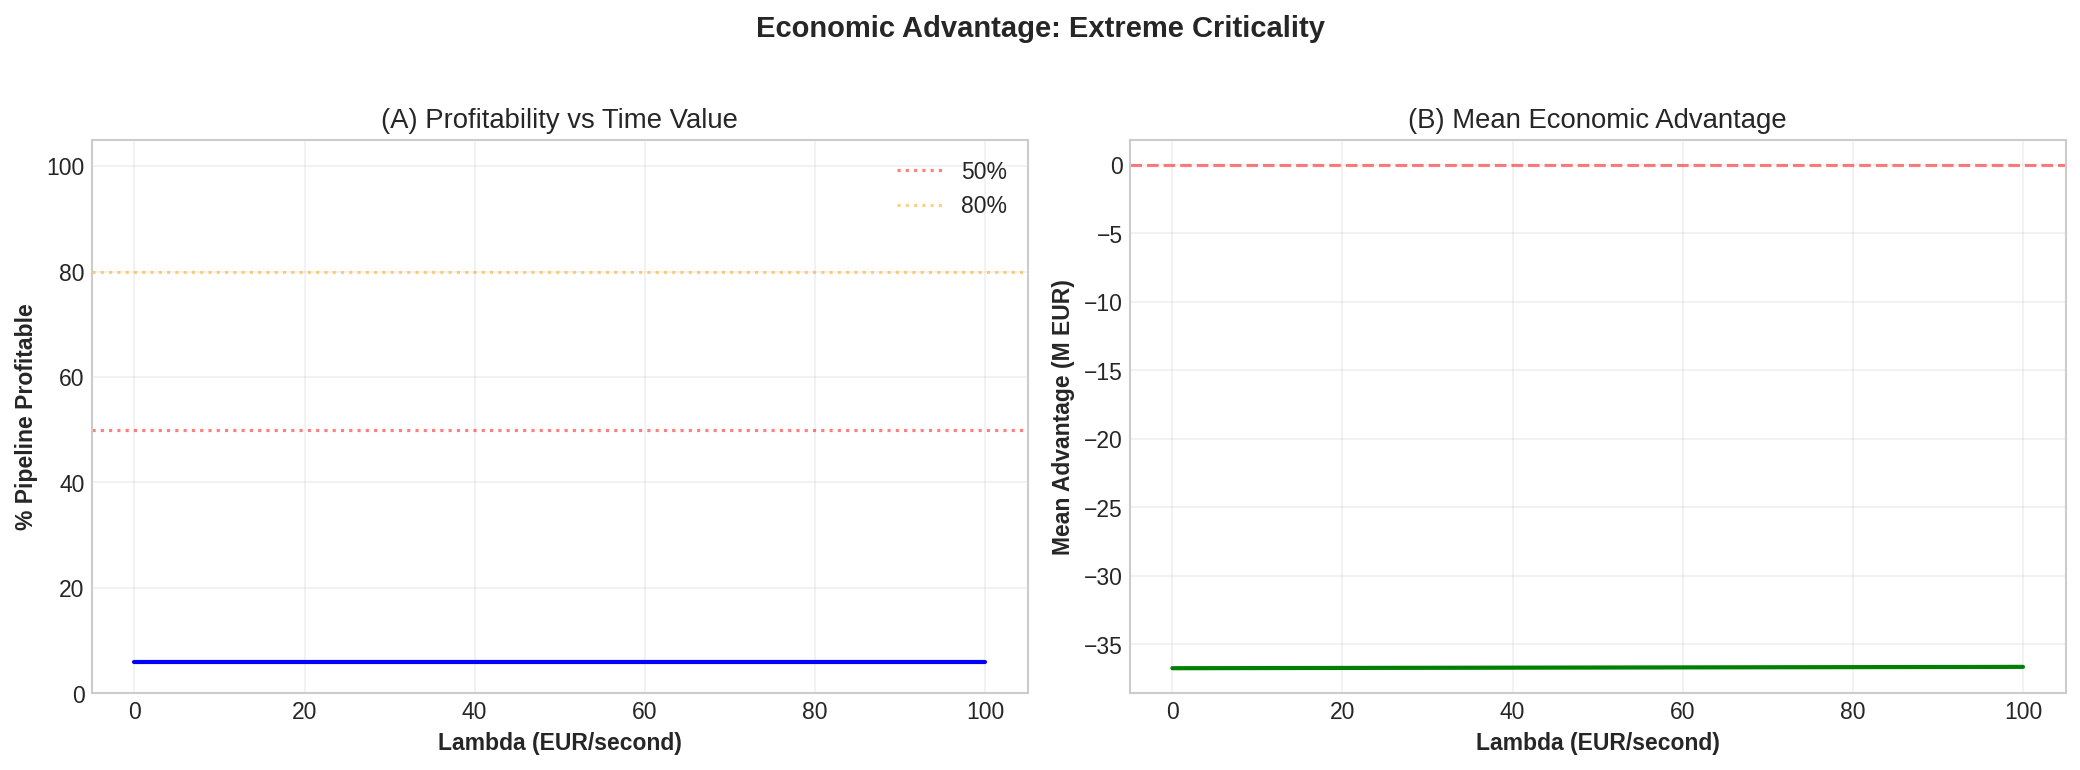

ECONOMIC ADVANTAGE: Extreme Criticality (n=100)
Breakeven lambda (50%): 1000.00 EUR/s
Breakeven lambda (80%): 1000.00 EUR/s
  lambda=1: 6.0% profitable, mean advantage=-36.73 MEUR
  lambda=5: 6.0% profitable, mean advantage=-36.73 MEUR
  lambda=10: 6.0% profitable, mean advantage=-36.72 MEUR
  lambda=20: 6.0% profitable, mean advantage=-36.71 MEUR
  lambda=50: 6.0% profitable, mean advantage=-36.68 MEUR
  lambda=100: 6.0% profitable, mean advantage=-36.63 MEUR


In [16]:
from src.eval.economic_advantage import EconomicAdvantageAnalyzer

econ = EconomicAdvantageAnalyzer(df)
sensitivity_df = econ.sensitivity_analysis()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: % Profitable vs Lambda
ax = axes[0]
ax.plot(sensitivity_df['lambda'], sensitivity_df['pct_profitable'], 'b-', lw=2)
ax.axhline(y=50, color='red', linestyle=':', alpha=0.5, label='50%')
ax.axhline(y=80, color='orange', linestyle=':', alpha=0.5, label='80%')
ax.set_xlabel('Lambda (EUR/second)', fontweight='bold')
ax.set_ylabel('% Pipeline Profitable', fontweight='bold')
ax.set_title('(A) Profitability vs Time Value')
ax.legend(); ax.grid(True, alpha=0.3); ax.set_ylim(0, 105)

# Panel B: Mean advantage
ax = axes[1]
ax.plot(sensitivity_df['lambda'], sensitivity_df['mean_advantage'] / 1e6, 'g-', lw=2)
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax.set_xlabel('Lambda (EUR/second)', fontweight='bold')
ax.set_ylabel('Mean Advantage (M EUR)', fontweight='bold')
ax.set_title('(B) Mean Economic Advantage')
ax.grid(True, alpha=0.3)

fig.suptitle('Economic Advantage: Extreme Criticality', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig5_extreme_economic_advantage.png', dpi=300, bbox_inches='tight')
plt.show()

summary = econ.compute_summary(lambda_values=[1, 5, 10, 20, 50, 100])
print('=' * 70)
print(f'ECONOMIC ADVANTAGE: Extreme Criticality (n={len(df)})')
print('=' * 70)
print(f'Breakeven lambda (50%): {summary["breakeven_lambda_50pct"]:.2f} EUR/s')
print(f'Breakeven lambda (80%): {summary["breakeven_lambda_80pct"]:.2f} EUR/s')
for key, val in summary.items():
    if key.startswith('lambda_'):
        lam = key.replace('lambda_', '')
        print(f'  lambda={lam}: {val["pct_profitable"]:.1f}% profitable, '
              f'mean advantage={val["mean_advantage_eur"]/1e6:.2f} MEUR')

## 13. Correlation: Criticality Components vs Pipeline Performance

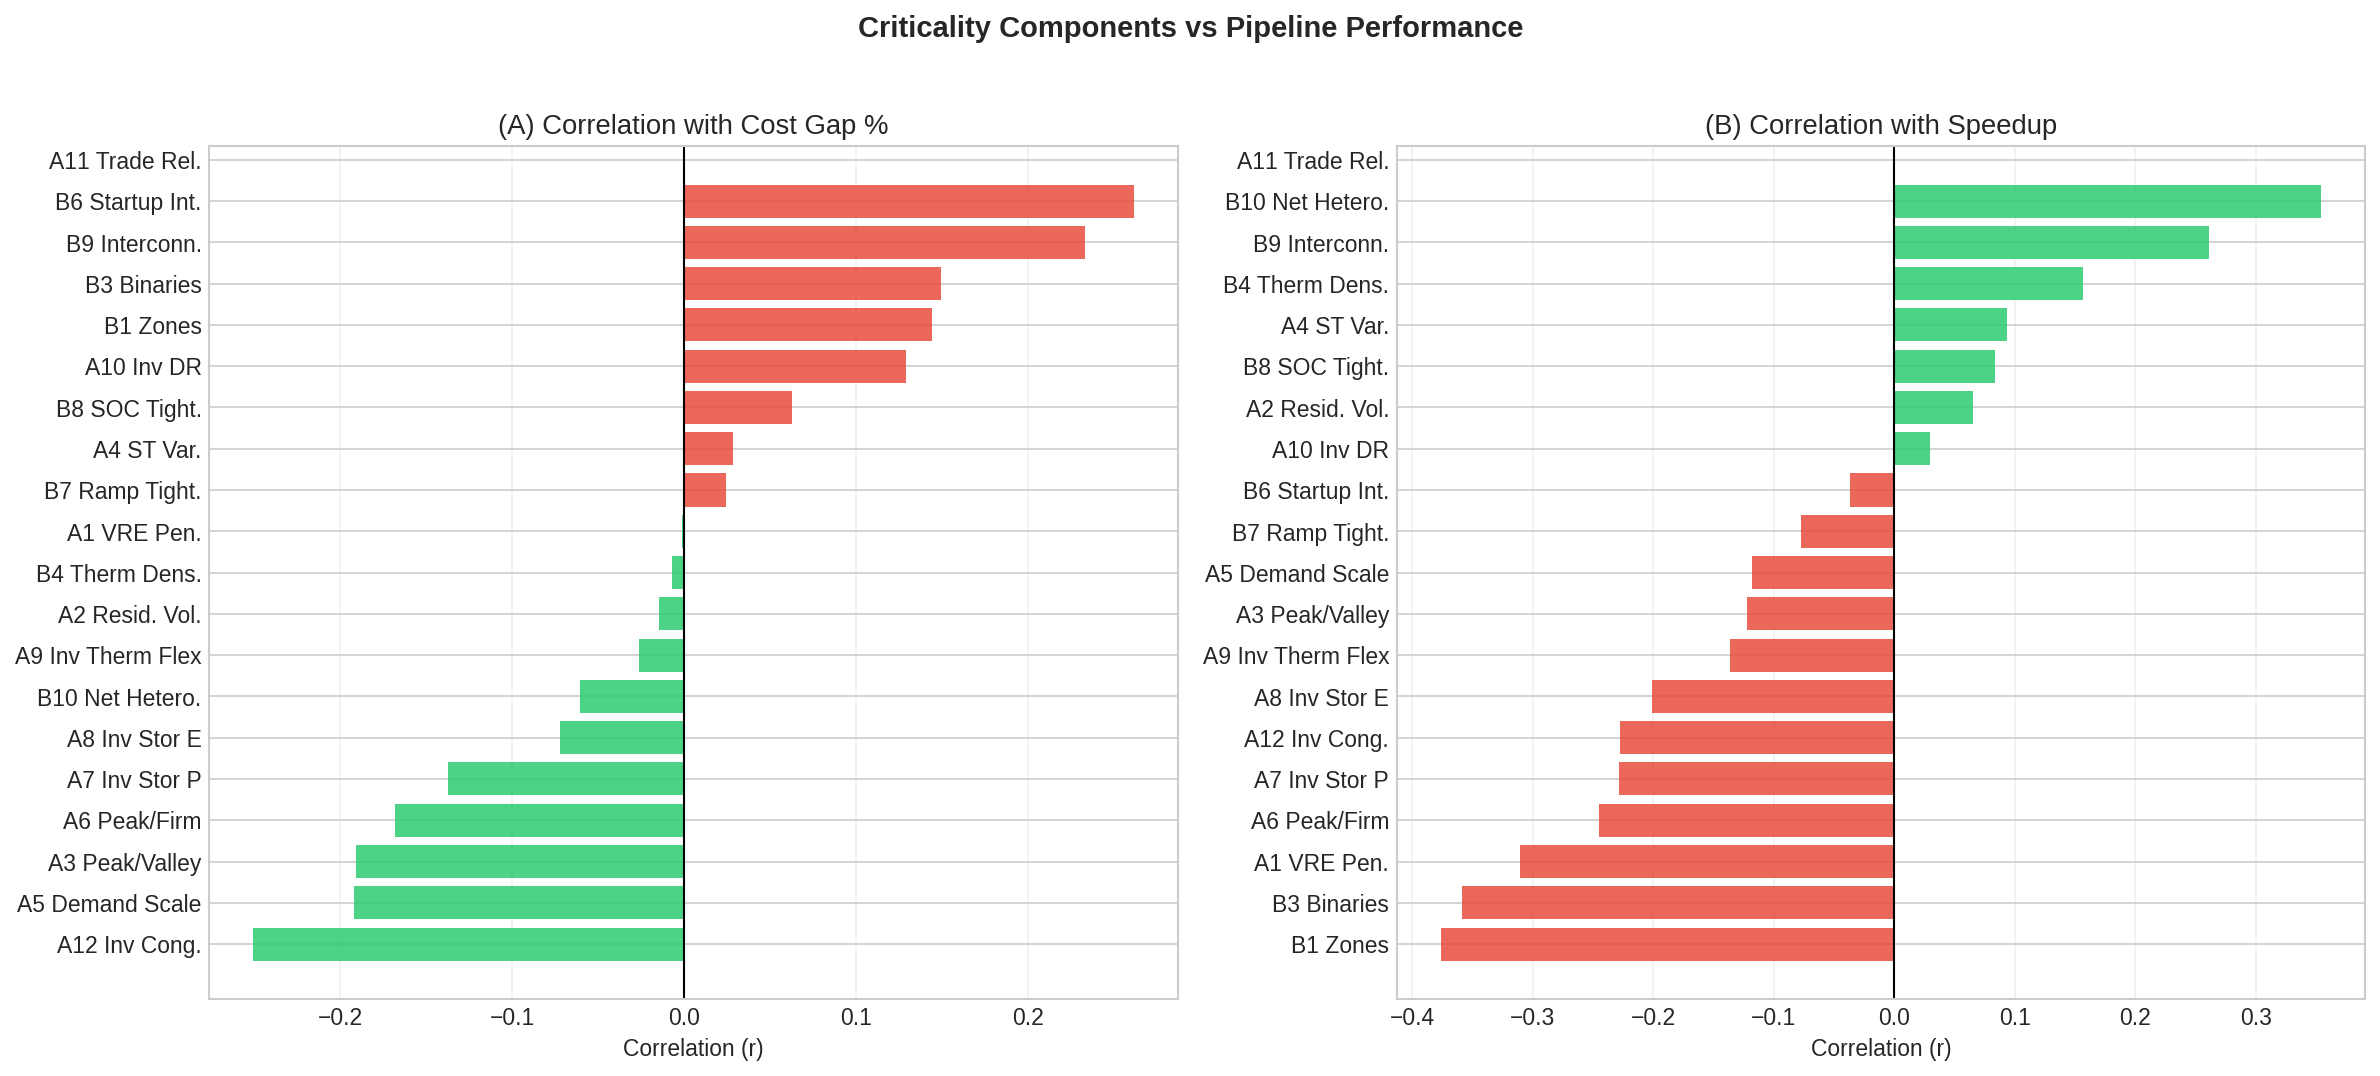

In [17]:
# Merge criticality decomposition with pipeline results
df_merged = df.merge(df_crit, on='scenario_id', how='left', suffixes=('', '_crit'))

corr_cols = [c for c in all_norm_cols if c in df_merged.columns]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Panel A: Correlation with cost_gap_pct
ax = axes[0]
corrs_gap = df_merged[corr_cols + ['cost_gap_pct']].corr()['cost_gap_pct'].drop('cost_gap_pct')
sorted_gap = corrs_gap.sort_values()
colors_g = ['#e74c3c' if v > 0 else '#2ecc71' for v in sorted_gap.values]
labels_g = [all_labels[all_norm_cols.index(c)] for c in sorted_gap.index]
ax.barh(labels_g, sorted_gap.values, color=colors_g, alpha=0.85)
ax.set_xlabel('Correlation (r)')
ax.set_title('(A) Correlation with Cost Gap %')
ax.axvline(x=0, color='black', linewidth=1)
ax.grid(True, alpha=0.3, axis='x')

# Panel B: Correlation with speedup
ax = axes[1]
corrs_sp = df_merged[corr_cols + ['speedup']].corr()['speedup'].drop('speedup')
sorted_sp = corrs_sp.sort_values()
colors_sp = ['#2ecc71' if v > 0 else '#e74c3c' for v in sorted_sp.values]
labels_sp = [all_labels[all_norm_cols.index(c)] for c in sorted_sp.index]
ax.barh(labels_sp, sorted_sp.values, color=colors_sp, alpha=0.85)
ax.set_xlabel('Correlation (r)')
ax.set_title('(B) Correlation with Speedup')
ax.axvline(x=0, color='black', linewidth=1)
ax.grid(True, alpha=0.3, axis='x')

fig.suptitle('Criticality Components vs Pipeline Performance',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig6_extreme_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

## 14. Final Summary

In [18]:
print('=' * 90)
print('EXTREME CRITICALITY EVALUATION SUMMARY')
print('=' * 90)
print(f'\nScenarios:         {len(df)}')
print(f'Success rate:      {df["success"].mean()*100:.1f}%')
print(f'MaxTimeLimit rate: {len(df_tl)}/{len(df)} ({len(df_tl)/max(len(df),1)*100:.0f}%)')
print(f'\nCriticality index: mean={df_crit["criticality_index"].mean():.4f} '
      f'[{df_crit["criticality_index"].min():.4f}-{df_crit["criticality_index"].max():.4f}]')

print(f'\n--- All scenarios ---')
print(f'  Pipeline time:   mean={df["pipeline_solve_time"].mean():.1f}s, median={df["pipeline_solve_time"].median():.1f}s')
print(f'  MILP time:       mean={df["milp_solve_time"].mean():.1f}s, median={df["milp_solve_time"].median():.1f}s')
print(f'  Speedup:         mean={df["speedup"].mean():.1f}x, median={df["speedup"].median():.1f}x')
print(f'  Cost gap:        P50={df["cost_gap_pct"].median():.1f}%, P90={np.percentile(df["cost_gap_pct"].dropna(), 90):.1f}%')
n_better_all = (df['cost_gap_pct'] < 0).sum()
print(f'  Pipeline better: {n_better_all}/{len(df)} ({n_better_all/max(len(df),1)*100:.0f}%)')
print(f'  Stage dist:      {dict(df["pipeline_stage"].value_counts())}')

if len(df_tl) > 0:
    print(f'\n--- MaxTimeLimit subset (n={len(df_tl)}) ---')
    print(f'  Pipeline time:   mean={df_tl["pipeline_solve_time"].mean():.1f}s, median={df_tl["pipeline_solve_time"].median():.1f}s')
    print(f'  MILP time:       mean={df_tl["milp_solve_time"].mean():.1f}s')
    print(f'  Speedup:         mean={df_tl["speedup"].mean():.1f}x, median={df_tl["speedup"].median():.1f}x')
    print(f'  Cost gap:        P50={df_tl["cost_gap_pct"].median():.1f}%')
    n_better_tl = (df_tl['cost_gap_pct'] < 0).sum()
    print(f'  Pipeline better: {n_better_tl}/{len(df_tl)} ({n_better_tl/max(len(df_tl),1)*100:.0f}%)')

# Save full merged DataFrame
df_merged.to_csv(OUTPUT_DIR / 'extreme_criticality_full_comparison.csv', index=False)
print(f'\nSaved to {OUTPUT_DIR / "extreme_criticality_full_comparison.csv"}')
print('=' * 90)

EXTREME CRITICALITY EVALUATION SUMMARY

Scenarios:         100
Success rate:      100.0%
MaxTimeLimit rate: 100/100 (100%)

Criticality index: mean=0.5413 [0.5336-0.5588]

--- All scenarios ---
  Pipeline time:   mean=224.9s, median=223.4s
  MILP time:       mean=1208.8s, median=1208.7s
  Speedup:         mean=5.8x, median=5.4x
  Cost gap:        P50=119.6%, P90=602.2%
  Pipeline better: 6/100 (6%)
  Stage dist:      {'hard_fix': np.int64(48), 'repair_20': np.int64(46), 'full_soft': np.int64(6)}

--- MaxTimeLimit subset (n=100) ---
  Pipeline time:   mean=224.9s, median=223.4s
  MILP time:       mean=1208.8s
  Speedup:         mean=5.8x, median=5.4x
  Cost gap:        P50=119.6%
  Pipeline better: 6/100 (6%)

Saved to /content/drive/MyDrive/benchmark/outputs/pipeline_eval_extreme/extreme_criticality_full_comparison.csv
